In [7]:
# Cell 1: Install dependencies (if needed)
# Uncomment for Google Colab
# !pip install psutil

print("Installing dependencies...")

Installing dependencies...


In [1]:
#Cell 2
# Import  libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import cv2
from PIL import Image
import json
import time
from datetime import datetime
import platform
import psutil

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, InceptionV3
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

#  style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries imported successfully")
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

All libraries imported successfully
TensorFlow Version: 2.19.0
GPU Available: True


DATASET Configurations

In [2]:
#Configuration
#Cell 3
DATASET_PATH = "/content/drive/MyDrive/DEEPLearning-Classification/Multi Classified coins"


OUTPUT_DIR = "/content/drive/MyDrive/CoinResultsCloud"
BATCH_SIZE = 32
EPOCHS = 20
IMG_SIZE_MOBILE = (224, 224)
IMG_SIZE_INCEPTION = (299, 299)

# Create output directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/eda", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/models", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/results", exist_ok=True)

print(f"Configuration set!")
print(f"Dataset Path: {DATASET_PATH}")
print(f"Output Directory: {OUTPUT_DIR}")

Configuration set!
Dataset Path: /content/drive/MyDrive/DEEPLearning-Classification/Multi Classified coins
Output Directory: results


####EDA

In [8]:
# Cell 4: Load dataset information

print("LOADING DATASET INFORMATION")

image_files = []
labels = []

# Iterate through subdirectories (each subdirectory is a class)
for class_folder in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_folder)

    # Skip if not a directory
    if not os.path.isdir(class_path):
        continue

    # Iterate through images in each class folder
    for filename in os.listdir(class_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            # Store full path to image
            full_path = os.path.join(class_path, filename)
            image_files.append(full_path)
            labels.append(class_folder)  # Folder name is the label

class_names = sorted(list(set(labels)))
num_classes = len(class_names)

print(f"\nTotal Images: {len(image_files)}")
print(f"Number of Classes: {num_classes}")
print(f"Classes: {class_names}")

# Show distribution of images per class
print("\nClass Distribution:")
from collections import Counter
label_counts = Counter(labels)
for class_name in class_names:
    print(f"  {class_name}: {label_counts[class_name]} images")

LOADING DATASET INFORMATION

Total Images: 660
Number of Classes: 6
Classes: ['1-pound', '10p', '20p', '2pounds', '50p', '5p']

Class Distribution:
  1-pound: 87 images
  10p: 132 images
  20p: 132 images
  2pounds: 94 images
  50p: 127 images
  5p: 88 images


###Class Distribution

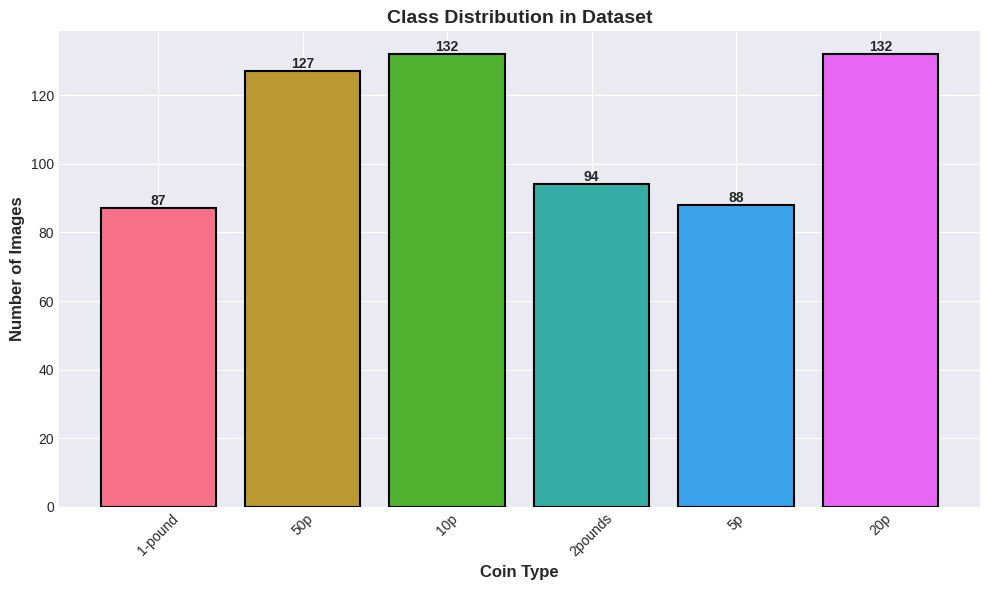


Class Distribution:
  1-pound: 87 images (13.18%)
  10p: 132 images (20.00%)
  20p: 132 images (20.00%)
  2pounds: 94 images (14.24%)
  50p: 127 images (19.24%)
  5p: 88 images (13.33%)

Imbalance Ratio: 1.52
 Dataset is reasonably balanced


In [4]:
# Cell 5: Visualize Class Distribution

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Use label_counts from Cell 4 (or recreate it)
class_counts = Counter(labels)

plt.figure(figsize=(10, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=sns.color_palette("husl", len(class_counts)),
               edgecolor='black', linewidth=1.5)
plt.xlabel('Coin Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda/class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\nClass Distribution:")
for coin_type in class_names:  # Use sorted class_names from Cell 4
    count = class_counts[coin_type]
    percentage = (count / len(labels)) * 100
    print(f"  {coin_type}: {count} images ({percentage:.2f}%)")

# Check balance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")
if imbalance_ratio > 2:
    print("  Dataset is IMBALANCED - consider data augmentation")
else:
    print(" Dataset is reasonably balanced")

###Image Dimensions


Analyzing image dimensions...


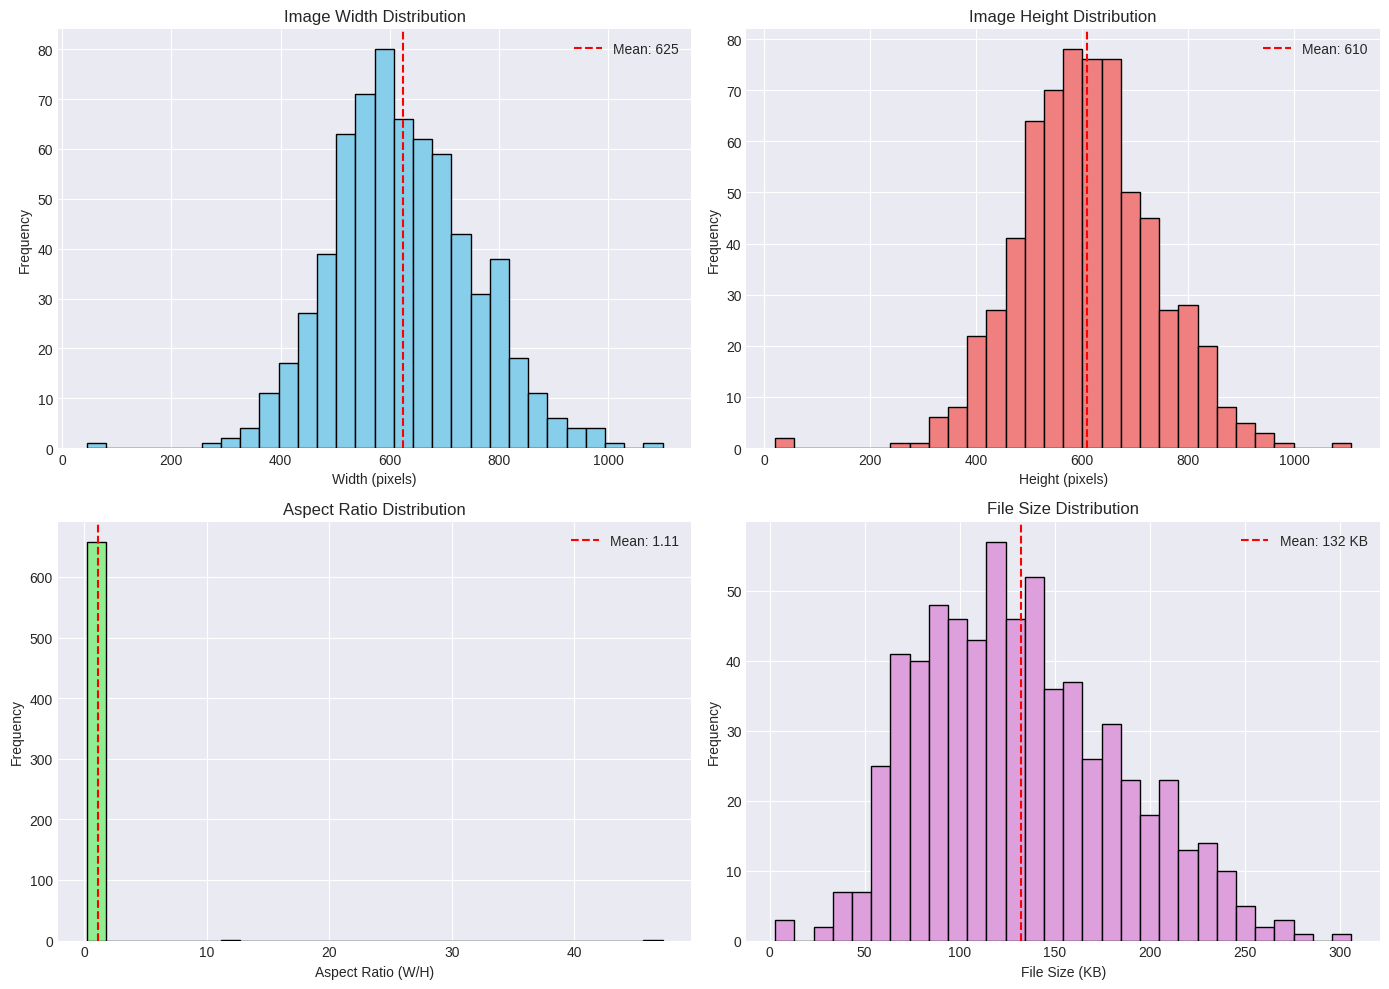


Width  - Mean: 624.86, Min: 45, Max: 1099
Height - Mean: 609.69, Min: 21, Max: 1108
File Size - Mean: 132.18 KB, Total: 85.19 MB


In [5]:
# Cell 6: Image Dimensions Analysis

widths, heights, aspect_ratios, file_sizes = [], [], [], []

print("\nAnalyzing image dimensions...")
for img_path in image_files:  # image_files already contains full paths
    img = Image.open(img_path)
    width, height = img.size
    widths.append(width)
    heights.append(height)
    aspect_ratios.append(width / height)
    file_sizes.append(os.path.getsize(img_path) / 1024)  # KB

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Width
axes[0, 0].hist(widths, bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Image Width Distribution')
axes[0, 0].axvline(np.mean(widths), color='red', linestyle='--',
                   label=f'Mean: {np.mean(widths):.0f}')
axes[0, 0].legend()

# Height
axes[0, 1].hist(heights, bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Image Height Distribution')
axes[0, 1].axvline(np.mean(heights), color='red', linestyle='--',
                   label=f'Mean: {np.mean(heights):.0f}')
axes[0, 1].legend()

# Aspect ratio
axes[1, 0].hist(aspect_ratios, bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Aspect Ratio (W/H)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Aspect Ratio Distribution')
axes[1, 0].axvline(np.mean(aspect_ratios), color='red', linestyle='--',
                   label=f'Mean: {np.mean(aspect_ratios):.2f}')
axes[1, 0].legend()

# File size
axes[1, 1].hist(file_sizes, bins=30, color='plum', edgecolor='black')
axes[1, 1].set_xlabel('File Size (KB)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('File Size Distribution')
axes[1, 1].axvline(np.mean(file_sizes), color='red', linestyle='--',
                   label=f'Mean: {np.mean(file_sizes):.0f} KB')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda/image_dimensions.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nWidth  - Mean: {np.mean(widths):.2f}, Min: {np.min(widths)}, Max: {np.max(widths)}")
print(f"Height - Mean: {np.mean(heights):.2f}, Min: {np.min(heights)}, Max: {np.max(heights)}")
print(f"File Size - Mean: {np.mean(file_sizes):.2f} KB, Total: {np.sum(file_sizes)/1024:.2f} MB")

###Image Viusalisations

In [6]:
#   Images Visualization
# Cell 7
samples_per_class = 5
unique_labels = sorted(set(labels))

fig, axes = plt.subplots(num_classes, samples_per_class,
                         figsize=(samples_per_class*3, num_classes*3))

if num_classes == 1:
    axes = axes.reshape(1, -1)

for i, label in enumerate(unique_labels):
    class_images = [f for f, l in zip(image_files, labels) if l == label]
    sample_images = np.random.choice(class_images,
                                    min(samples_per_class, len(class_images)),
                                    replace=False)

    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(DATASET_PATH, img_name)
        img = Image.open(img_path)

        axes[i, j].imshow(img)
        axes[i, j].axis('off')

        if j == 0:
            axes[i, j].set_title(f'{label}', fontsize=12, fontweight='bold')

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda/sample_images.png", dpi=300, bbox_inches='tight')
plt.show()



Output hidden; open in https://colab.research.google.com to view.

###Data Preprocessing/Preparation

Train/Test/Split

In [9]:
# Cell 8: Create train/val/test splits

print("DATA PREPARATION")


# All image paths , labels
image_paths = [os.path.join(DATASET_PATH, f) for f in image_files]
label_to_index = {label: idx for idx, label in enumerate(class_names)}
labels_encoded = [label_to_index[label] for label in labels]

print(f"\nTotal samples: {len(image_paths)}")

# Split: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels_encoded,
    test_size=0.15,
    random_state=SEED,
    stratify=labels_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15 / 0.85,
    random_state=SEED,
    stratify=y_temp
)

print(f"\nTrain: {len(X_train)} ({len(X_train)/len(image_paths)*100:.1f}%)")
print(f"Val:   {len(X_val)} ({len(X_val)/len(image_paths)*100:.1f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/len(image_paths)*100:.1f}%)")

DATA PREPARATION

Total samples: 660

Train: 462 (70.0%)
Val:   99 (15.0%)
Test:  99 (15.0%)


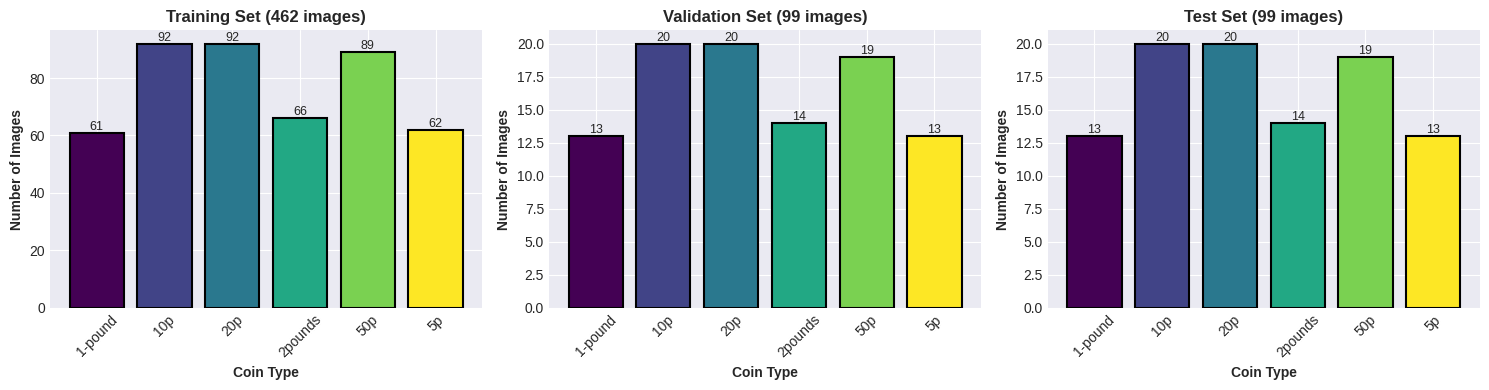

In [10]:
# Visualize split distribution
#Cell 9
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

splits = [
    ('Training', y_train),
    ('Validation', y_val),
    ('Test', y_test)
]

for ax, (split_name, split_labels) in zip(axes, splits):
    counts = np.bincount(split_labels, minlength=num_classes)
    bars = ax.bar(class_names, counts, color=plt.cm.viridis(np.linspace(0, 1, num_classes)),
                  edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Coin Type', fontweight='bold')
    ax.set_ylabel('Number of Images', fontweight='bold')
    ax.set_title(f'{split_name} Set ({len(split_labels)} images)', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda/data_split.png", dpi=300, bbox_inches='tight')
plt.show()

Training MobileNEt

In [42]:
# Cell 10: CORRECTED - Create TensorFlow datasets with proper preprocessing
def create_dataset(image_paths, labels, img_size, batch_size, model_type='resnet', shuffle=True, augment=False):
    """
    Create TensorFlow dataset with MODEL-SPECIFIC preprocessing

    Args:
        model_type: 'resnet' or 'inception'
    """
    def load_and_preprocess(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, img_size)
        image = tf.cast(image, tf.float32)
        # NO normalization here - will be done by model-specific preprocessing
        return image, label

    @tf.function
    def augment_image(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.2)
        image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
        image = tf.clip_by_value(image, 0.0, 255.0)  # Keep in [0, 255] range
        return image, label

    # Model-specific preprocessing function
    @tf.function
    def apply_model_preprocessing(image, label):
        if model_type == 'resnet':
            # ResNet50 preprocessing (caffe mode - subtracts mean RGB)
            image = tf.keras.applications.resnet50.preprocess_input(image)
        elif model_type == 'inception':
            # InceptionV3 preprocessing (scales to [-1, 1])
            image = tf.keras.applications.inception_v3.preprocess_input(image)
        return image, label

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths))

    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    # Apply model-specific preprocessing
    dataset = dataset.map(apply_model_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

print("✓ CORRECTED dataset creation function ready!")

✓ CORRECTED dataset creation function ready!


Trainng

In [43]:
# Cell 11 & 12 CORRECTED - RESNET50 with proper preprocessing
from tensorflow.keras.applications import ResNet50

print("="*80)
print("BUILDING & TRAINING RESNET50")
print("="*80)

# Create datasets with ResNet50-specific preprocessing
train_dataset_resnet = create_dataset(X_train, y_train, IMG_SIZE_MOBILE, BATCH_SIZE,
                                     model_type='resnet', shuffle=True, augment=True)
val_dataset_resnet = create_dataset(X_val, y_val, IMG_SIZE_MOBILE, BATCH_SIZE,
                                   model_type='resnet', shuffle=False, augment=False)
test_dataset_resnet = create_dataset(X_test, y_test, IMG_SIZE_MOBILE, BATCH_SIZE,
                                    model_type='resnet', shuffle=False, augment=False)

# Build ResNet50 model
base = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE_MOBILE, 3))
base.trainable = False

model_resnet = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name='ResNet50_Classifier')

model_resnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ ResNet50 built!")
model_resnet.summary()

# Train
start_time = time.time()
history_resnet = model_resnet.fit(
    train_dataset_resnet,
    validation_data=val_dataset_resnet,
    epochs=EPOCHS,
    verbose=1
)
training_time_resnet = time.time() - start_time

print(f"\n✓ Done in {training_time_resnet/60:.2f} min")
model_resnet.save(f"{OUTPUT_DIR}/models/resnet50_final.keras")

BUILDING & TRAINING RESNET50
✓ ResNet50 built!


Model: "ResNet50_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,926 (92.11 MB)

 Trainable params: 558,214 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3642 - loss: 1.7689 - val_accuracy: 0.9394 - val_loss: 0.3782
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 336ms/step - accuracy: 0.7931 - loss: 0.5736 - val_accuracy: 0.9899 - val_loss: 0.0798
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 241ms/step - accuracy: 0.9335 - loss: 0.2304 - val_accuracy: 1.0000 - val_loss: 0.0288
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 311ms/step - accuracy: 0.9708 - loss: 0.1065 - val_accuracy: 0.9899 - val_loss: 0.0273
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.9591 - loss: 0.1025 - val_accuracy: 0.9899 - val_loss: 0.0410
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 244ms/step - accuracy: 0.9908 - loss: 0.0490 - val_accuracy: 0.9899 - val_loss: 0.0312
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 285ms/step - accuracy: 0.9925 - loss: 0.0315 - val_accuracy: 0.9899 - val_loss: 0.0365
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 256ms/step - accuracy: 0.9784 - loss: 0.0468 - val_accuracy: 0.98

In [54]:
# ============================================================================
# Cell 13: EVALUATE RESNET50 & GENERATE PREDICTIONS
# ============================================================================
print("="*80)
print("RESNET50 - EVALUATION & PREDICTION GENERATION")
print("="*80)

# 1. Evaluate on test set
print("\n1️⃣ EVALUATING ON TEST SET...")
test_loss_resnet, test_accuracy_resnet = model_resnet.evaluate(test_dataset_resnet, verbose=1)

# 2. Generate predictions for detailed analysis
print("\n2️⃣ GENERATING PREDICTIONS...")
y_pred_resnet = []
y_true = []

for images, labels in test_dataset_resnet:
    predictions = model_resnet.predict(images, verbose=0)
    y_pred_resnet.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_pred_resnet = np.array(y_pred_resnet)
y_true = np.array(y_true)

# 3. Print results
print("\n" + "="*80)
print("📊 TEST RESULTS")
print("="*80)
print(f"Test Loss:     {test_loss_resnet:.4f}")
print(f"Test Accuracy: {test_accuracy_resnet*100:.2f}%")
print(f"Total Test Samples: {len(y_true)}")

# 4. Training summary
print("\n" + "="*80)
print("📈 TRAINING SUMMARY")
print("="*80)
final_train_acc = history_resnet.history['accuracy'][-1]
final_val_acc = history_resnet.history['val_accuracy'][-1]
best_val_acc = max(history_resnet.history['val_accuracy'])

print(f"Final Training Accuracy:   {final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"Best Validation Accuracy:  {best_val_acc*100:.2f}%")
print(f"Test Accuracy:             {test_accuracy_resnet*100:.2f}%")

# 5. Overfitting check
train_val_gap = (final_train_acc - final_val_acc) * 100
print(f"\n🔍 OVERFITTING CHECK:")
print(f"Train-Val Gap: {train_val_gap:.2f}%")
if train_val_gap < 5:
    print("✅ NO OVERFITTING detected")
elif train_val_gap < 10:
    print("⚡ SLIGHT OVERFITTING detected")
else:
    print("⚠️ OVERFITTING detected")

# 6. Classification Report
print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_true, y_pred_resnet, target_names=class_names, digits=4))

# 7. Save results
results_resnet = {
    'test_loss': float(test_loss_resnet),
    'test_accuracy': float(test_accuracy_resnet),
    'final_train_accuracy': float(final_train_acc),
    'final_val_accuracy': float(final_val_acc),
    'best_val_accuracy': float(best_val_acc),
    'training_time_minutes': training_time_resnet / 60
}

with open(f"{OUTPUT_DIR}/results/resnet50_results.json", 'w') as f:
    json.dump(results_resnet, f, indent=4)

print("\n✅ ResNet50 evaluation complete!")
print("✅ Variables created: y_true, y_pred_resnet")

RESNET50 - EVALUATION & PREDICTION GENERATION

1️⃣ EVALUATING ON TEST SET...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.9754 - loss: 0.0945

2️⃣ GENERATING PREDICTIONS...

📊 TEST RESULTS
Test Loss:     0.1334
Test Accuracy: 96.97%
Total Test Samples: 99

📈 TRAINING SUMMARY
Final Training Accuracy:   99.57%
Final Validation Accuracy: 98.99%
Best Validation Accuracy:  100.00%
Test Accuracy:             96.97%

🔍 OVERFITTING CHECK:
Train-Val Gap: 0.58%
✅ NO OVERFITTING detected

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

     1-pound     1.0000    0.8462    0.9167        13
         10p     1.0000    1.0000    1.0000        20
         20p     0.9524    1.0000    0.9756        20
     2pounds     0.9333    1.0000    0.9655        14
         50p     1.0000    1.0000    1.0000        19
          5p     0.9231    0.9231    0.9231        13

    accuracy                         0.9697        99
   macro avg     0.9681    0.9615    0.9635        

In [48]:
# Cell 14 & 15 CORRECTED - INCEPTIONV3 with proper preprocessing
from tensorflow.keras.applications import InceptionV3

print("="*80)
print("BUILDING & TRAINING INCEPTIONV3")
print("="*80)

# Create datasets with InceptionV3-specific preprocessing
train_dataset_inception = create_dataset(X_train, y_train, IMG_SIZE_INCEPTION, BATCH_SIZE,
                                        model_type='inception', shuffle=True, augment=True)
val_dataset_inception = create_dataset(X_val, y_val, IMG_SIZE_INCEPTION, BATCH_SIZE,
                                      model_type='inception', shuffle=False, augment=False)
test_dataset_inception = create_dataset(X_test, y_test, IMG_SIZE_INCEPTION, BATCH_SIZE,
                                       model_type='inception', shuffle=False, augment=False)

# Build InceptionV3 model
base = InceptionV3(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE_INCEPTION, 3))
base.trainable = False

model_inception = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name='InceptionV3_Classifier')

model_inception.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ InceptionV3 built!")
model_inception.summary()

# Train
start_time = time.time()
history_inception = model_inception.fit(
    train_dataset_inception,
    validation_data=val_dataset_inception,
    epochs=EPOCHS,
    verbose=1
)
training_time_inception = time.time() - start_time

print(f"\n✓ Done in {training_time_inception/60:.2f} min")
model_inception.save(f"{OUTPUT_DIR}/models/inceptionv3_final.keras")

BUILDING & TRAINING INCEPTIONV3
✓ InceptionV3 built!


Model: "InceptionV3_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,360,998 (85.30 MB)

 Trainable params: 558,214 (2.13 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.3255 - loss: 1.6854 - val_accuracy: 0.6667 - val_loss: 0.9040
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 0.6651 - loss: 1.0085 - val_accuracy: 0.9697 - val_loss: 0.3045
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 0.8574 - loss: 0.4869 - val_accuracy: 0.9697 - val_loss: 0.1656
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 299ms/step - accuracy: 0.9205 - loss: 0.2751 - val_accuracy: 0.9697 - val_loss: 0.1095
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - accuracy: 0.9338 - loss: 0.2082 - val_accuracy: 0.9798 - val_loss: 0.0952
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - accuracy: 0.9690 - loss: 0.1757 - val_accuracy: 0.9798 - val_loss: 0.0552
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 238ms/step - accuracy: 0.9930 - loss: 0.0911 - val_accuracy: 0.9798 - val_loss: 0.0463
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 293ms/step - accuracy: 0.9816 - loss: 0.0663 - val_accuracy: 0.98

In [55]:
# ============================================================================
# Cell 16: EVALUATE INCEPTIONV3 & GENERATE PREDICTIONS
# ============================================================================
print("="*80)
print("INCEPTIONV3 - EVALUATION & PREDICTION GENERATION")
print("="*80)

# 1. Evaluate on test set
print("\n1️⃣ EVALUATING ON TEST SET...")
test_loss_inc, test_accuracy_inc = model_inception.evaluate(test_dataset_inception, verbose=1)

# 2. Generate predictions for detailed analysis
print("\n2️⃣ GENERATING PREDICTIONS...")
y_pred_inception = []
y_true_inception = []

for images, labels in test_dataset_inception:
    predictions = model_inception.predict(images, verbose=0)
    y_pred_inception.extend(np.argmax(predictions, axis=1))
    y_true_inception.extend(labels.numpy())

y_pred_inception = np.array(y_pred_inception)
y_true_inception = np.array(y_true_inception)

# 3. Print results
print("\n" + "="*80)
print("📊 TEST RESULTS")
print("="*80)
print(f"Test Loss:     {test_loss_inc:.4f}")
print(f"Test Accuracy: {test_accuracy_inc*100:.2f}%")
print(f"Total Test Samples: {len(y_true_inception)}")

# 4. Training summary
print("\n" + "="*80)
print("📈 TRAINING SUMMARY")
print("="*80)
final_train_acc_inc = history_inception.history['accuracy'][-1]
final_val_acc_inc = history_inception.history['val_accuracy'][-1]
best_val_acc_inc = max(history_inception.history['val_accuracy'])

print(f"Final Training Accuracy:   {final_train_acc_inc*100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc_inc*100:.2f}%")
print(f"Best Validation Accuracy:  {best_val_acc_inc*100:.2f}%")
print(f"Test Accuracy:             {test_accuracy_inc*100:.2f}%")

# 5. Overfitting check
train_val_gap = (final_train_acc_inc - final_val_acc_inc) * 100
print(f"\n🔍 OVERFITTING CHECK:")
print(f"Train-Val Gap: {train_val_gap:.2f}%")
if train_val_gap < 5:
    print("✅ NO OVERFITTING detected")
elif train_val_gap < 10:
    print("⚡ SLIGHT OVERFITTING detected")
else:
    print("⚠️ OVERFITTING detected")

# 6. Classification Report
print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_true_inception, y_pred_inception, target_names=class_names, digits=4))

# 7. Save results
results_inception = {
    'test_loss': float(test_loss_inc),
    'test_accuracy': float(test_accuracy_inc),
    'final_train_accuracy': float(final_train_acc_inc),
    'final_val_accuracy': float(final_val_acc_inc),
    'best_val_accuracy': float(best_val_acc_inc),
    'training_time_minutes': training_time_inception / 60
}

with open(f"{OUTPUT_DIR}/results/inceptionv3_results.json", 'w') as f:
    json.dump(results_inception, f, indent=4)

print("\n✅ InceptionV3 evaluation complete!")
print("✅ Variables created: y_true_inception, y_pred_inception")

INCEPTIONV3 - EVALUATION & PREDICTION GENERATION

1️⃣ EVALUATING ON TEST SET...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.9846 - loss: 0.0730

2️⃣ GENERATING PREDICTIONS...



📊 TEST RESULTS
Test Loss:     0.1085
Test Accuracy: 97.98%
Total Test Samples: 99

📈 TRAINING SUMMARY
Final Training Accuracy:   99.57%
Final Validation Accuracy: 98.99%
Best Validation Accuracy:  98.99%
Test Accuracy:             97.98%

🔍 OVERFITTING CHECK:
Train-Val Gap: 0.58%
✅ NO OVERFITTING detected

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

     1-pound     1.0000    0.9231    0.9600        13
         10p     1.0000    1.0000    1.0000        20
         20p     0.9524    1.0000    0.9756        20
     2pounds     1.0000    1.0000    1.0000        14
         50p     1.0000    1.0000    1.0000        19
          5p     0.9231    0.9231    0.9231        13

    accuracy                         0.9798        99
   macro avg     0.9792    0.9744    0.9764        99
weighted avg     0.9803    0.9798    0.9797        99


✅ InceptionV3 evaluation complete!
✅ Variables created: y_true_inception, y_pred_inception


RESNET50 - CONFUSION MATRIX


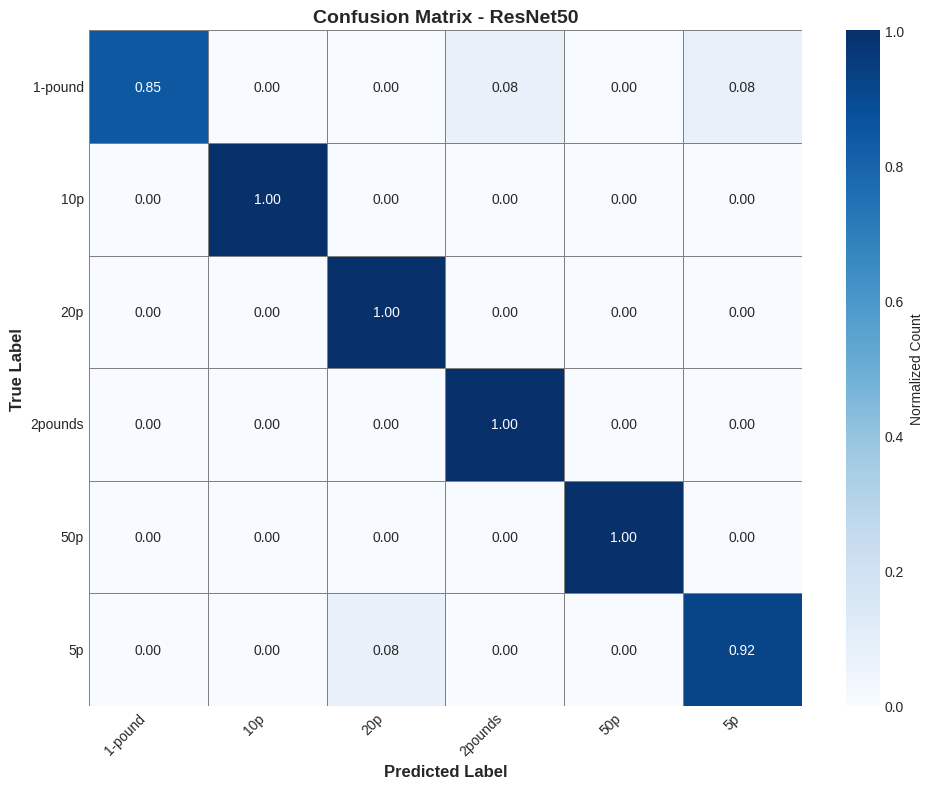

✅ Confusion matrix saved!


In [56]:
# ============================================================================
# Cell 17: RESNET50 CONFUSION MATRIX
# ============================================================================
print("="*80)
print("RESNET50 - CONFUSION MATRIX")
print("="*80)

# Calculate confusion matrix
cm_resnet = confusion_matrix(y_test, y_pred_resnet)
cm_normalized = cm_resnet.astype('float') / cm_resnet.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names,
           cbar_kws={'label': 'Normalized Count'},
           linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - ResNet50', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/results/resnet50_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved!")

RESNET50 - PER-CLASS ACCURACY
  1-pound   : 84.62% (13 samples)
  10p       : 100.00% (20 samples)
  20p       : 100.00% (20 samples)
  2pounds   : 100.00% (14 samples)
  50p       : 100.00% (19 samples)
  5p        : 92.31% (13 samples)


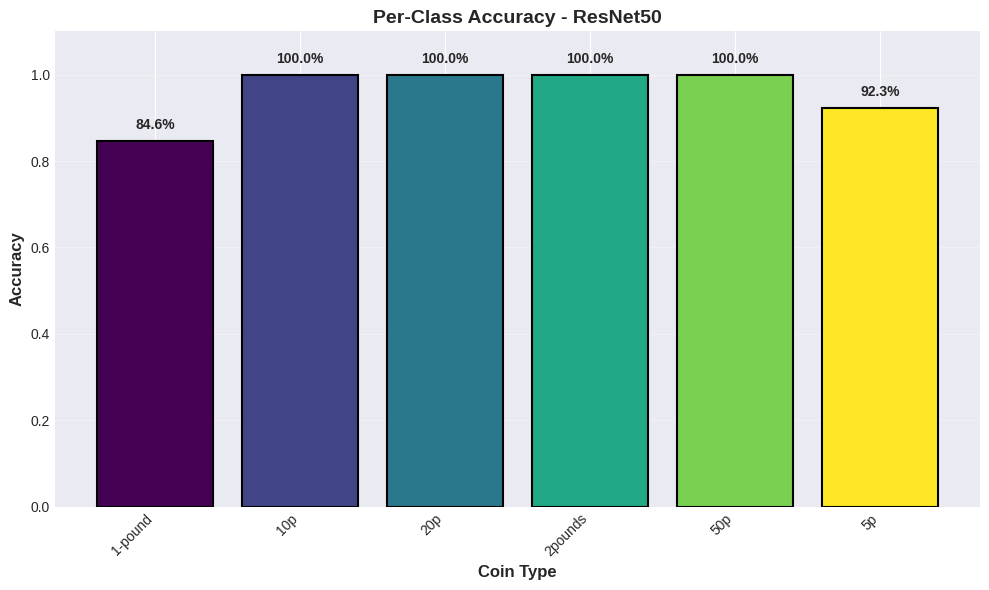

✅ Per-class accuracy plot saved!


In [57]:
# ============================================================================
# Cell 18: RESNET50 PER-CLASS ACCURACY
# ============================================================================
print("="*80)
print("RESNET50 - PER-CLASS ACCURACY")
print("="*80)

# Calculate per-class accuracy
per_class_acc_resnet = {}
for i, class_name in enumerate(class_names):
    class_mask = y_true == i
    if np.sum(class_mask) > 0:
        class_acc = np.mean(y_pred_resnet[class_mask] == y_true[class_mask])
        per_class_acc_resnet[class_name] = class_acc
        print(f"  {class_name:10s}: {class_acc*100:.2f}% ({np.sum(class_mask)} samples)")

# Plot
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
bars = plt.bar(class_names, per_class_acc_resnet.values(), color=colors,
              edgecolor='black', linewidth=1.5)
plt.xlabel('Coin Type', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Per-Class Accuracy - ResNet50', fontsize=14, fontweight='bold')
plt.ylim([0, 1.1])
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/results/resnet50_per_class_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Per-class accuracy plot saved!")

INCEPTIONV3 - CONFUSION MATRIX


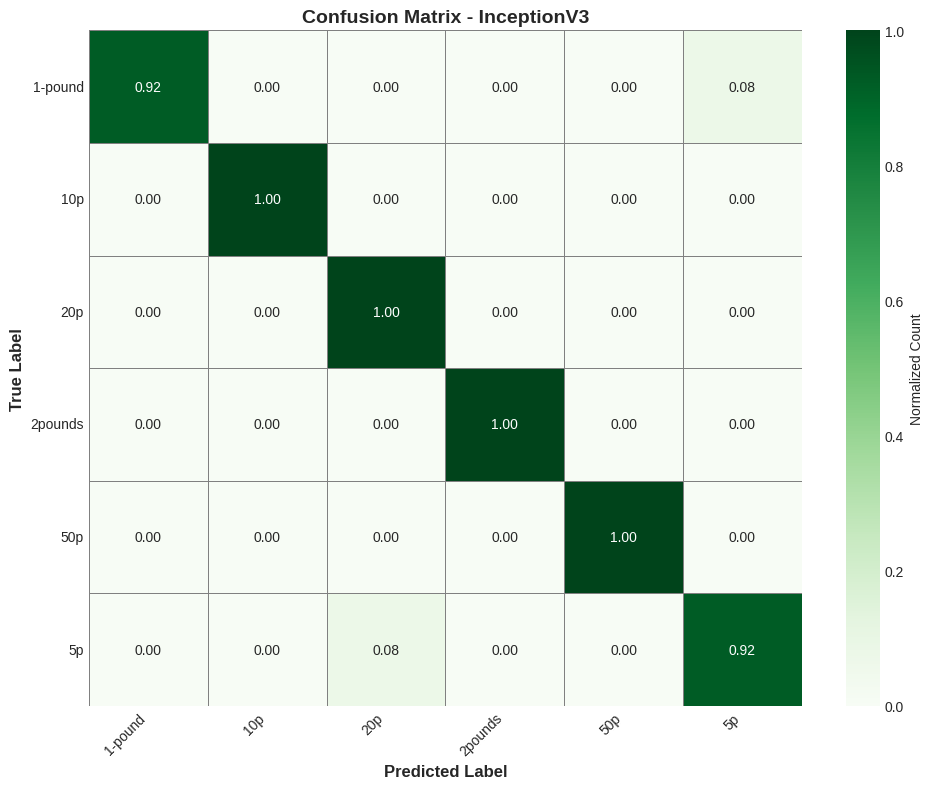

✅ Confusion matrix saved!


In [58]:
# ============================================================================
# Cell 19: INCEPTIONV3 CONFUSION MATRIX
# ============================================================================
print("="*80)
print("INCEPTIONV3 - CONFUSION MATRIX")
print("="*80)

# Calculate confusion matrix
cm_inception = confusion_matrix(y_true_inception, y_pred_inception)
cm_normalized_inc = cm_inception.astype('float') / cm_inception.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized_inc, annot=True, fmt='.2f', cmap='Greens',
           xticklabels=class_names, yticklabels=class_names,
           cbar_kws={'label': 'Normalized Count'},
           linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - InceptionV3', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/results/inceptionv3_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved!")

INCEPTIONV3 - PER-CLASS ACCURACY
  1-pound   : 92.31% (13 samples)
  10p       : 100.00% (20 samples)
  20p       : 100.00% (20 samples)
  2pounds   : 100.00% (14 samples)
  50p       : 100.00% (19 samples)
  5p        : 92.31% (13 samples)


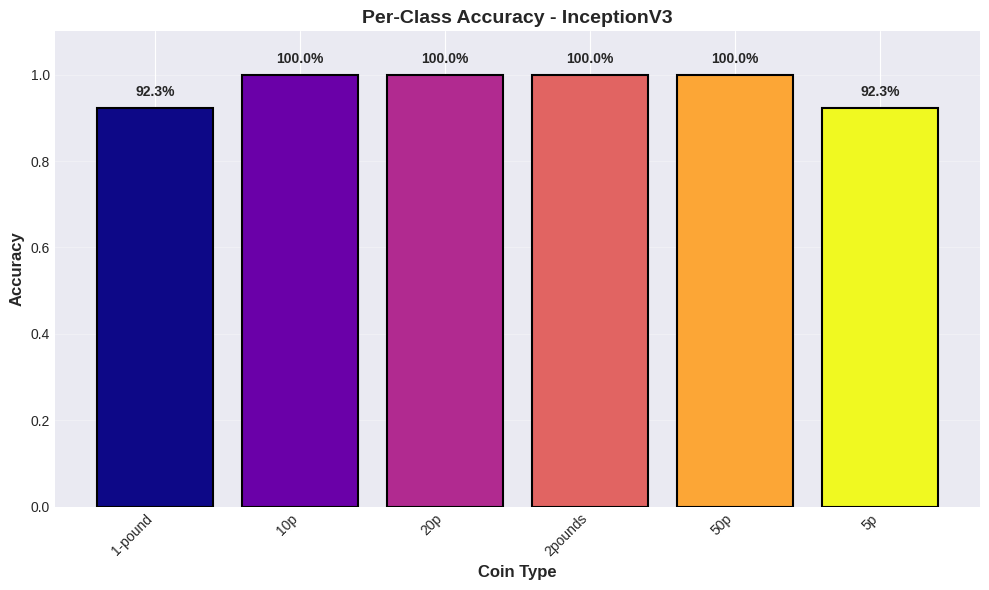

✅ Per-class accuracy plot saved!


In [59]:
# ============================================================================
# Cell 20: INCEPTIONV3 PER-CLASS ACCURACY
# ============================================================================
print("="*80)
print("INCEPTIONV3 - PER-CLASS ACCURACY")
print("="*80)

# Calculate per-class accuracy
per_class_acc_inception = {}
for i, class_name in enumerate(class_names):
    class_mask = y_true_inception == i
    if np.sum(class_mask) > 0:
        class_acc = np.mean(y_pred_inception[class_mask] == y_true_inception[class_mask])
        per_class_acc_inception[class_name] = class_acc
        print(f"  {class_name:10s}: {class_acc*100:.2f}% ({np.sum(class_mask)} samples)")

# Plot
plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0, 1, len(class_names)))
bars = plt.bar(class_names, per_class_acc_inception.values(), color=colors,
              edgecolor='black', linewidth=1.5)
plt.xlabel('Coin Type', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Per-Class Accuracy - InceptionV3', fontsize=14, fontweight='bold')
plt.ylim([0, 1.1])
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/results/inceptionv3_per_class_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Per-class accuracy plot saved!")

In [60]:
# ============================================================================
# Cell 21: COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================================
print("="*80)
print("MODEL COMPARISON: ResNet50 vs InceptionV3")
print("="*80)

# Gather all metrics
comparison_data = {
    'Metric': [
        'Test Accuracy (%)',
        'Test Loss',
        'Training Time (min)',
        'Total Parameters',
        'Trainable Parameters',
        'Input Size',
        'Model Size (approx)',
        'Best Val Accuracy (%)',
        'Final Train Accuracy (%)'
    ],
    'ResNet50': [
        f"{results_resnet['test_accuracy'] * 100:.2f}",
        f"{results_resnet['test_loss']:.4f}",
        f"{results_resnet['training_time_minutes']:.2f}",
        f"{model_resnet.count_params():,}",
        f"{sum([tf.size(w).numpy() for w in model_resnet.trainable_weights]):,}",
        "224 × 224",
        "~98 MB",
        f"{results_resnet['best_val_accuracy'] * 100:.2f}",
        f"{results_resnet['final_train_accuracy'] * 100:.2f}"
    ],
    'InceptionV3': [
        f"{results_inception['test_accuracy'] * 100:.2f}",
        f"{results_inception['test_loss']:.4f}",
        f"{results_inception['training_time_minutes']:.2f}",
        f"{model_inception.count_params():,}",
        f"{sum([tf.size(w).numpy() for w in model_inception.trainable_weights]):,}",
        "299 × 299",
        "~92 MB",
        f"{results_inception['best_val_accuracy'] * 100:.2f}",
        f"{results_inception['final_train_accuracy'] * 100:.2f}"
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print(df_comparison.to_string(index=False))
print("="*80)

# Save to CSV
df_comparison.to_csv(f"{OUTPUT_DIR}/results/model_comparison.csv", index=False)
print("\n✅ Comparison table saved to CSV!")

# Calculate which model is better
resnet_acc = results_resnet['test_accuracy']
inception_acc = results_inception['test_accuracy']

print("\n" + "="*80)
print("📊 PERFORMANCE SUMMARY")
print("="*80)

if resnet_acc > inception_acc:
    diff = (resnet_acc - inception_acc) * 100
    print(f"🏆 ResNet50 performs better by {diff:.2f} percentage points")
elif inception_acc > resnet_acc:
    diff = (inception_acc - resnet_acc) * 100
    print(f"🏆 InceptionV3 performs better by {diff:.2f} percentage points")
else:
    print("🤝 Both models perform equally!")

# Training efficiency
if results_resnet['training_time_minutes'] < results_inception['training_time_minutes']:
    time_diff = results_inception['training_time_minutes'] - results_resnet['training_time_minutes']
    print(f"⚡ ResNet50 trains {time_diff:.2f} minutes faster")
else:
    time_diff = results_resnet['training_time_minutes'] - results_inception['training_time_minutes']
    print(f"⚡ InceptionV3 trains {time_diff:.2f} minutes faster")

MODEL COMPARISON: ResNet50 vs InceptionV3

                  Metric   ResNet50 InceptionV3
       Test Accuracy (%)      96.97       97.98
               Test Loss     0.1334      0.1085
     Training Time (min)       1.94        2.08
        Total Parameters 24,145,926  22,360,998
    Trainable Parameters    558,214     558,214
              Input Size  224 × 224   299 × 299
     Model Size (approx)     ~98 MB      ~92 MB
   Best Val Accuracy (%)     100.00       98.99
Final Train Accuracy (%)      99.57       99.57

✅ Comparison table saved to CSV!

📊 PERFORMANCE SUMMARY
🏆 InceptionV3 performs better by 1.01 percentage points
⚡ ResNet50 trains 0.14 minutes faster


GENERATING COMPARISON VISUALIZATIONS


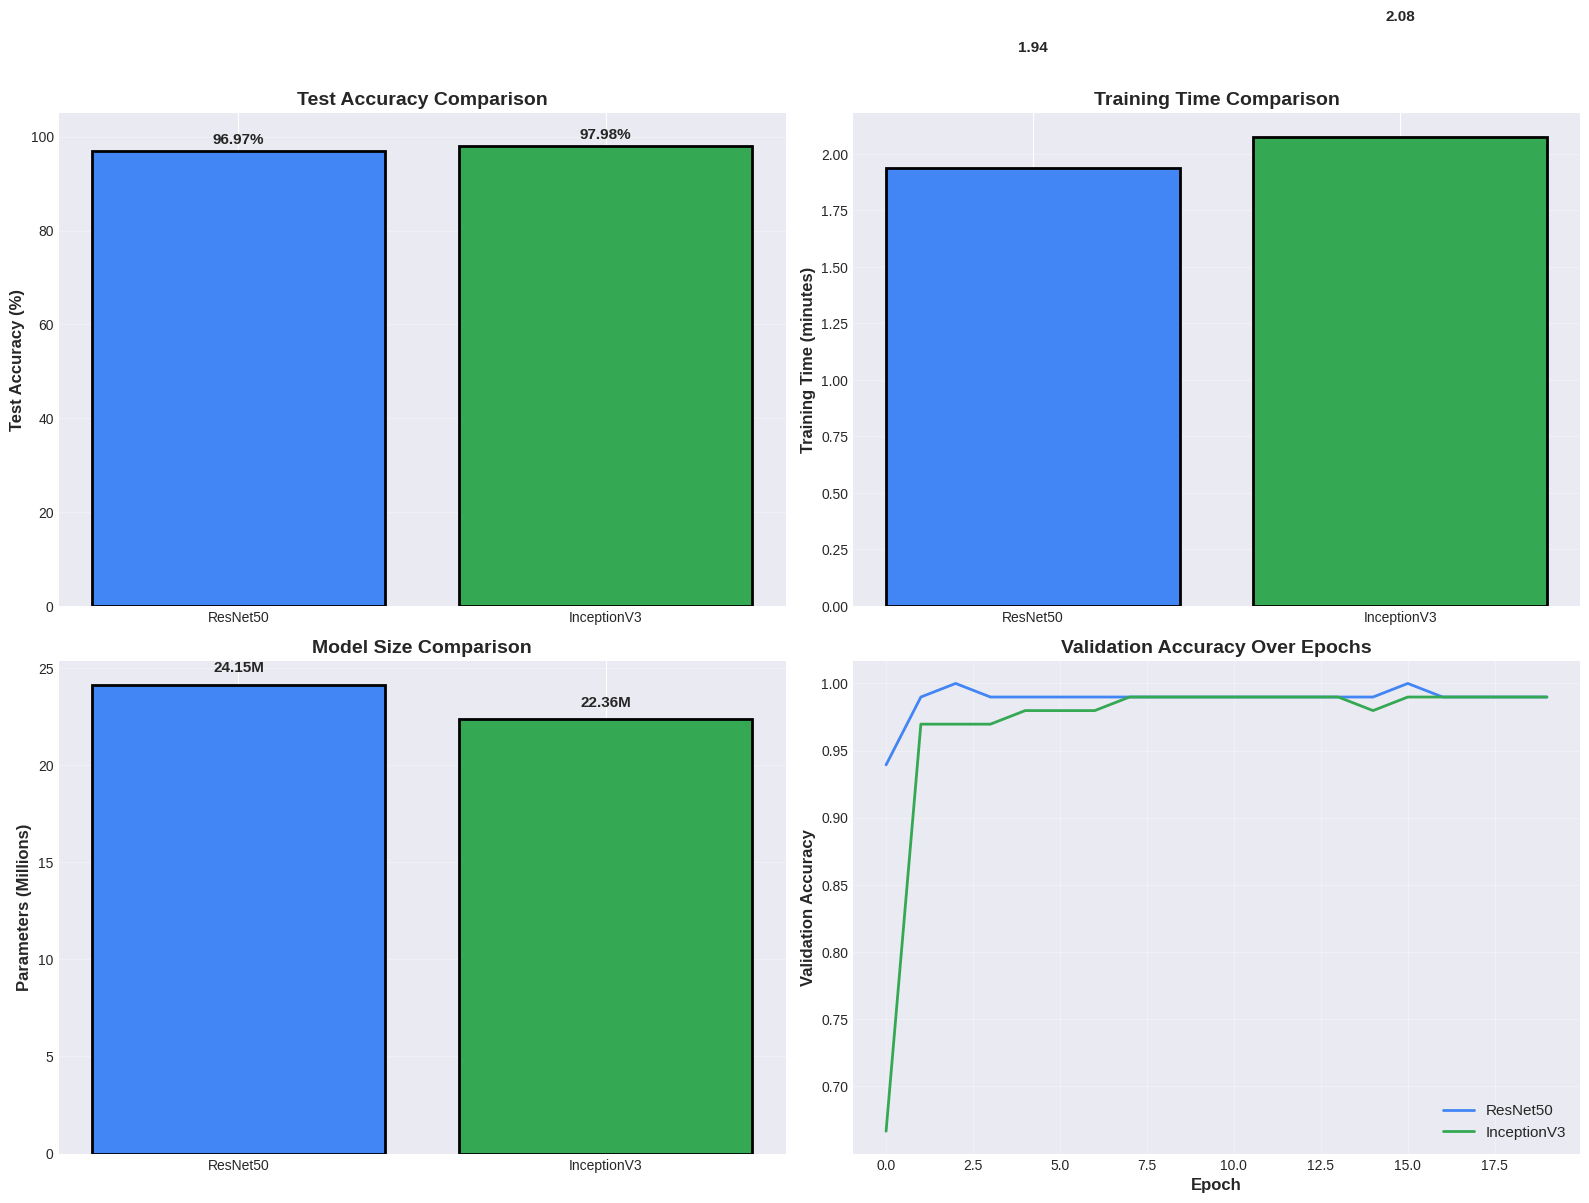

✅ Comparison visualizations saved!


In [63]:
# ============================================================================
# Cell 22: VISUAL MODEL COMPARISON
# ============================================================================
print("="*80)
print("GENERATING COMPARISON VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = ['ResNet50', 'InceptionV3']

# 1. Test Accuracy Comparison
accuracies = [results_resnet['test_accuracy'] * 100, results_inception['test_accuracy'] * 100]
bars1 = axes[0, 0].bar(models, accuracies, color=['#4285F4', '#34A853'],
                       edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim([0, 105])
axes[0, 0].grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.2f}%', ha='center', va='bottom',
                    fontweight='bold', fontsize=11)

# 2. Training Time Comparison
times = [results_resnet['training_time_minutes'], results_inception['training_time_minutes']]
bars2 = axes[0, 1].bar(models, times, color=['#4285F4', '#34A853'],
                       edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Training Time (minutes)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.2f}', ha='center', va='bottom',
                    fontweight='bold', fontsize=11)

# 3. Parameters Comparison
params = [model_resnet.count_params() / 1e6, model_inception.count_params() / 1e6]
bars3 = axes[1, 0].bar(models, params, color=['#4285F4', '#34A853'],
                       edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Parameters (Millions)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Model Size Comparison', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

for bar in bars3:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.2f}M', ha='center', va='bottom',
                    fontweight='bold', fontsize=11)

# 4. Training History Comparison
axes[1, 1].plot(history_resnet.history['val_accuracy'],
               label='ResNet50', linewidth=2, color='#4285F4')
axes[1, 1].plot(history_inception.history['val_accuracy'],
               label='InceptionV3', linewidth=2, color='#34A853')
axes[1, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/results/model_comparison_plots.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comparison visualizations saved!")

PER-CLASS ACCURACY COMPARISON

 Coin Type  ResNet50 (%)  InceptionV3 (%)
  1-pound     84.615385        92.307692
      10p    100.000000       100.000000
      20p    100.000000       100.000000
  2pounds    100.000000       100.000000
      50p    100.000000       100.000000
       5p     92.307692        92.307692


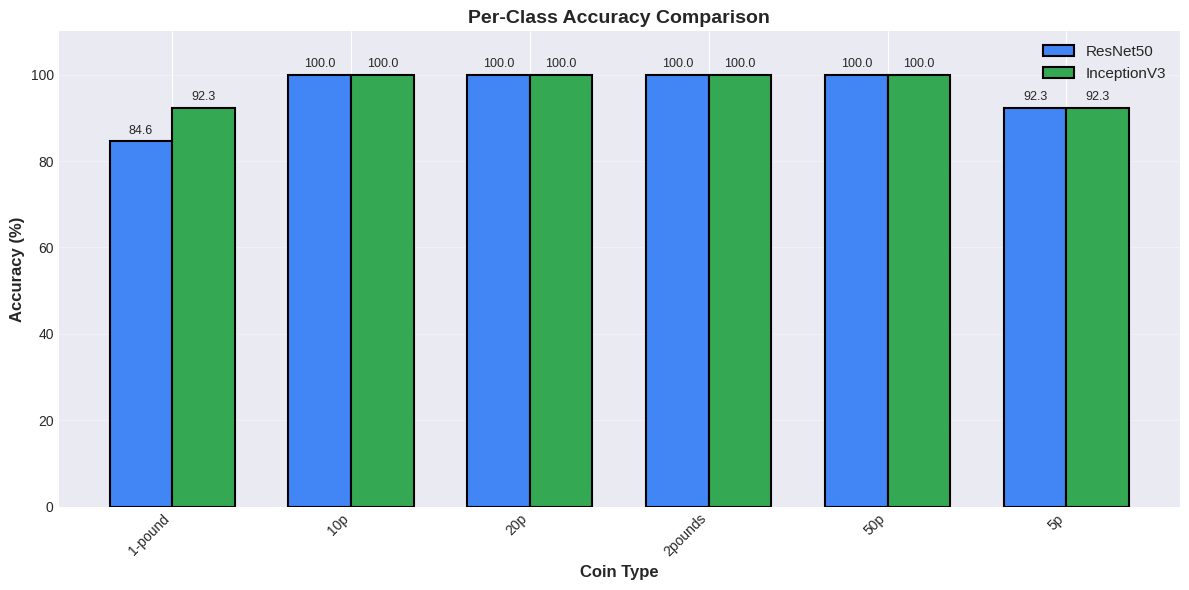


✅ Per-class comparison saved!


In [64]:
# ============================================================================
# Cell 23: PER-CLASS ACCURACY COMPARISON
# ============================================================================
print("="*80)
print("PER-CLASS ACCURACY COMPARISON")
print("="*80)

# Create comparison DataFrame
per_class_comparison = pd.DataFrame({
    'Coin Type': class_names,
    'ResNet50 (%)': [per_class_acc_resnet[c] * 100 for c in class_names],
    'InceptionV3 (%)': [per_class_acc_inception[c] * 100 for c in class_names]
})

print("\n", per_class_comparison.to_string(index=False))
per_class_comparison.to_csv(f"{OUTPUT_DIR}/results/per_class_comparison.csv", index=False)

# Plot side-by-side comparison
x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, per_class_comparison['ResNet50 (%)'], width,
              label='ResNet50', color='#4285F4', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, per_class_comparison['InceptionV3 (%)'], width,
              label='InceptionV3', color='#34A853', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Coin Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([0, 110])
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
               f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/results/per_class_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Per-class comparison saved!")

In [65]:
# ============================================================================
# Cell 24: COLLECT ENVIRONMENT INFORMATION
# ============================================================================
print("="*80)
print("ENVIRONMENT INFORMATION")
print("="*80)

env_info = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'platform': platform.system(),
    'platform_version': platform.version(),
    'python_version': platform.python_version(),
    'tensorflow_version': tf.__version__,
    'keras_version': tf.keras.__version__,
    'numpy_version': np.__version__,
    'pandas_version': pd.__version__,
    'matplotlib_version': plt.matplotlib.__version__,
    'seaborn_version': sns.__version__,
    'gpu_available': len(tf.config.list_physical_devices('GPU')) > 0,
    'gpu_count': len(tf.config.list_physical_devices('GPU')),
    'cpu_count_logical': psutil.cpu_count(logical=True),
    'cpu_count_physical': psutil.cpu_count(logical=False),
    'total_memory_gb': psutil.virtual_memory().total / (1024**3),
    'available_memory_gb': psutil.virtual_memory().available / (1024**3)
}

# Check if Colab
try:
    import google.colab
    env_info['environment'] = 'Google Colab'
    # Try to get GPU info
    gpu_info = !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
    if gpu_info:
        env_info['gpu_info'] = gpu_info[0]
except ImportError:
    env_info['environment'] = 'Local'

# Print formatted info
print(f"\n🖥️  ENVIRONMENT: {env_info['environment']}")
print(f"📅 Timestamp: {env_info['timestamp']}")
print(f"\n💻 SYSTEM:")
print(f"   Platform: {env_info['platform']}")
print(f"   Python: {env_info['python_version']}")
print(f"\n📚 LIBRARIES:")
print(f"   TensorFlow: {env_info['tensorflow_version']}")
print(f"   Keras: {env_info['keras_version']}")
print(f"   NumPy: {env_info['numpy_version']}")
print(f"   Pandas: {env_info['pandas_version']}")
print(f"   Matplotlib: {env_info['matplotlib_version']}")
print(f"   Seaborn: {env_info['seaborn_version']}")
print(f"\n🎮 HARDWARE:")
print(f"   GPU Available: {env_info['gpu_available']}")
if env_info['gpu_available']:
    print(f"   GPU Count: {env_info['gpu_count']}")
    if 'gpu_info' in env_info:
        print(f"   GPU Info: {env_info['gpu_info']}")
print(f"   CPU Cores (Logical): {env_info['cpu_count_logical']}")
print(f"   CPU Cores (Physical): {env_info['cpu_count_physical']}")
print(f"   Total RAM: {env_info['total_memory_gb']:.2f} GB")
print(f"   Available RAM: {env_info['available_memory_gb']:.2f} GB")

# Save to JSON
with open(f"{OUTPUT_DIR}/environment_info.json", 'w') as f:
    json.dump(env_info, f, indent=4)

# Save to text (more readable)
with open(f"{OUTPUT_DIR}/environment_info.txt", 'w') as f:
    f.write("="*80 + "\n")
    f.write("ENVIRONMENT INFORMATION\n")
    f.write("="*80 + "\n\n")
    f.write(f"Environment: {env_info['environment']}\n")
    f.write(f"Timestamp: {env_info['timestamp']}\n\n")
    f.write("SYSTEM:\n")
    f.write(f"  Platform: {env_info['platform']}\n")
    f.write(f"  Python: {env_info['python_version']}\n\n")
    f.write("LIBRARIES:\n")
    f.write(f"  TensorFlow: {env_info['tensorflow_version']}\n")
    f.write(f"  Keras: {env_info['keras_version']}\n")
    f.write(f"  NumPy: {env_info['numpy_version']}\n")
    f.write(f"  Pandas: {env_info['pandas_version']}\n")
    f.write(f"  Matplotlib: {env_info['matplotlib_version']}\n")
    f.write(f"  Seaborn: {env_info['seaborn_version']}\n\n")
    f.write("HARDWARE:\n")
    f.write(f"  GPU Available: {env_info['gpu_available']}\n")
    if env_info['gpu_available']:
        f.write(f"  GPU Count: {env_info['gpu_count']}\n")
        if 'gpu_info' in env_info:
            f.write(f"  GPU Info: {env_info['gpu_info']}\n")
    f.write(f"  CPU Cores: {env_info['cpu_count_logical']} (logical), {env_info['cpu_count_physical']} (physical)\n")
    f.write(f"  Total RAM: {env_info['total_memory_gb']:.2f} GB\n")

print("\n✅ Environment information saved!")

ENVIRONMENT INFORMATION

🖥️  ENVIRONMENT: Google Colab
📅 Timestamp: 2025-11-27 22:57:32

💻 SYSTEM:
   Platform: Linux
   Python: 3.12.12

📚 LIBRARIES:
   TensorFlow: 2.19.0
   Keras: 3.10.0
   NumPy: 2.0.2
   Pandas: 2.2.2
   Matplotlib: 3.10.0
   Seaborn: 0.13.2

🎮 HARDWARE:
   GPU Available: True
   GPU Count: 1
   GPU Info: Tesla T4, 15360 MiB
   CPU Cores (Logical): 2
   CPU Cores (Physical): 1
   Total RAM: 12.67 GB
   Available RAM: 4.75 GB

✅ Environment information saved!


In [66]:
# ============================================================================
# Cell 25: SAVE ALL METRICS TO SINGLE JSON
# ============================================================================
print("="*80)
print("SAVING COMPREHENSIVE METRICS")
print("="*80)

# Compile all metrics
all_metrics = {
    'experiment_info': {
        'environment': env_info['environment'],
        'timestamp': env_info['timestamp'],
        'dataset': {
            'total_images': len(image_files),
            'num_classes': num_classes,
            'class_names': class_names,
            'train_samples': len(X_train),
            'val_samples': len(X_val),
            'test_samples': len(X_test),
            'class_distribution': {name: int(count) for name, count in class_counts.items()}
        }
    },
    'training_config': {
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
        'loss_function': 'sparse_categorical_crossentropy',
        'data_augmentation': True,
        'random_seed': SEED
    },
    'resnet50': {
        'architecture': {
            'base_model': 'ResNet50',
            'input_size': '224x224',
            'total_parameters': int(model_resnet.count_params()),
            'trainable_parameters': int(sum([tf.size(w).numpy() for w in model_resnet.trainable_weights]))
        },
        'training_results': results_resnet,
        'per_class_accuracy': {k: float(v) for k, v in per_class_acc_resnet.items()}
    },
    'inceptionv3': {
        'architecture': {
            'base_model': 'InceptionV3',
            'input_size': '299x299',
            'total_parameters': int(model_inception.count_params()),
            'trainable_parameters': int(sum([tf.size(w).numpy() for w in model_inception.trainable_weights]))
        },
        'training_results': results_inception,
        'per_class_accuracy': {k: float(v) for k, v in per_class_acc_inception.items()}
    },
    'comparison': {
        'accuracy_difference': float(abs(results_resnet['test_accuracy'] - results_inception['test_accuracy']) * 100),
        'training_time_difference': float(abs(results_resnet['training_time_minutes'] - results_inception['training_time_minutes'])),
        'better_accuracy': 'ResNet50' if results_resnet['test_accuracy'] > results_inception['test_accuracy'] else 'InceptionV3',
        'faster_training': 'ResNet50' if results_resnet['training_time_minutes'] < results_inception['training_time_minutes'] else 'InceptionV3'
    }
}

# Save comprehensive metrics
with open(f"{OUTPUT_DIR}/comprehensive_metrics.json", 'w') as f:
    json.dump(all_metrics, f, indent=4)

print("✅ Comprehensive metrics saved to comprehensive_metrics.json")
print("\n" + "="*80)
print("🎉 ALL EXPERIMENTS COMPLETE!")
print("="*80)
print(f"\nAll results saved to: {OUTPUT_DIR}/")
print("\n📁 Generated Files:")
print("   EDA:")
print("     • class_distribution.png")
print("     • image_dimensions.png")
print("     • sample_images.png")
print("     • data_split.png")
print("\n   Models:")
print("     • resnet50_final.keras")
print("     • inceptionv3_final.keras")
print("\n   Results:")
print("     • resnet50_confusion_matrix.png")
print("     • resnet50_per_class_accuracy.png")
print("     • inceptionv3_confusion_matrix.png")
print("     • inceptionv3_per_class_accuracy.png")
print("     • model_comparison.csv")
print("     • model_comparison_plots.png")
print("     • per_class_comparison.png")
print("     • resnet50_results.json")
print("     • inceptionv3_results.json")
print("\n   Environment:")
print("     • environment_info.json")
print("     • environment_info.txt")
print("     • comprehensive_metrics.json")
print("\n" + "="*80)
print("✅ Ready for report writing!")
print("="*80)

SAVING COMPREHENSIVE METRICS
✅ Comprehensive metrics saved to comprehensive_metrics.json

🎉 ALL EXPERIMENTS COMPLETE!

All results saved to: results/

📁 Generated Files:
   EDA:
     • class_distribution.png
     • image_dimensions.png
     • sample_images.png
     • data_split.png

   Models:
     • resnet50_final.keras
     • inceptionv3_final.keras

   Results:
     • resnet50_confusion_matrix.png
     • resnet50_per_class_accuracy.png
     • inceptionv3_confusion_matrix.png
     • inceptionv3_per_class_accuracy.png
     • model_comparison.csv
     • model_comparison_plots.png
     • per_class_comparison.png
     • resnet50_results.json
     • inceptionv3_results.json

   Environment:
     • environment_info.json
     • environment_info.txt
     • comprehensive_metrics.json

✅ Ready for report writing!


In [67]:
# ============================================================================
# Copy Results to Google Drive
# ============================================================================
import shutil
import os

print("="*80)
print("COPYING RESULTS TO GOOGLE DRIVE")
print("="*80)

# Check if Drive is mounted
if not os.path.exists('/content/drive'):
    print("❌ Google Drive not mounted!")
    print("Please run: from google.colab import drive")
    print("            drive.mount('/content/drive')")
else:
    print("✅ Google Drive is mounted")

    # Define source and destination
    source_dir = '/content/results'
    drive_destination = '/content/drive/MyDrive/CoinResultsCloud'

    # Create destination if it doesn't exist
    os.makedirs(drive_destination, exist_ok=True)

    print(f"\n📁 Source: {source_dir}")
    print(f"📁 Destination: {drive_destination}")

    # Copy the entire folder
    print("\n🔄 Copying files...")

    if os.path.exists(source_dir):
        # Remove old results if they exist
        if os.path.exists(drive_destination):
            print("⚠️  Destination folder exists, removing old version...")
            shutil.rmtree(drive_destination)

        # Copy new results
        shutil.copytree(source_dir, drive_destination)

        # Count files
        total_files = sum([len(files) for r, d, files in os.walk(drive_destination)])

        print(f"\n✅ SUCCESS! Copied {total_files} files to Google Drive")
        print(f"\n📂 Your results are saved at:")
        print(f"   {drive_destination}")
        print(f"\n🔗 Access in Drive at: MyDrive/CoinResultsCloud/")

        # Show structure
        print("\n📋 Folder Structure:")
        for root, dirs, files in os.walk(drive_destination):
            level = root.replace(drive_destination, '').count(os.sep)
            indent = ' ' * 2 * level
            print(f'{indent}{os.path.basename(root)}/')
            subindent = ' ' * 2 * (level + 1)
            for file in files[:5]:  # Show first 5 files per folder
                print(f'{subindent}{file}')
            if len(files) > 5:
                print(f'{subindent}... and {len(files)-5} more files')
    else:
        print(f"❌ Source folder not found: {source_dir}")

print("\n" + "="*80)

COPYING RESULTS TO GOOGLE DRIVE
✅ Google Drive is mounted

📁 Source: /content/results
📁 Destination: /content/drive/MyDrive/CoinResultsCloud

🔄 Copying files...
⚠️  Destination folder exists, removing old version...

✅ SUCCESS! Copied 23 files to Google Drive

📂 Your results are saved at:
   /content/drive/MyDrive/CoinResultsCloud

🔗 Access in Drive at: MyDrive/CoinResultsCloud/

📋 Folder Structure:
CoinResultsCloud/
  environment_info.json
  comprehensive_metrics.json
  environment_info.txt
  eda/
    sample_images.png
    image_dimensions.png
    data_split.png
    class_distribution.png
  models/
    mobilenetv2_summary.txt
    resnet50_final.keras
    inceptionv3_final.keras
  results/
    model_comparison.csv
    inceptionv3_training_history.png
    per_class_comparison.csv
    resnet50_results.json
    mobilenetv2_training_history.png
    ... and 8 more files



In [68]:
import sklearn
import PIL
import cv2
import psutil

print("scikit-learn:", sklearn.__version__)
print("Pillow:", PIL.__version__)
print("opencv-python:", cv2.__version__)
print("psutil:", psutil.__version__)

scikit-learn: 1.6.1
Pillow: 11.3.0
opencv-python: 4.12.0
psutil: 5.9.5
